# Adding things together: Code
------------------------------------------------------------------------------------------------------------------
*Start: 13-05-2026, Latest change: 13-05-2026*

Based on the preliminaries of data exploration and data comprehension as well as a personally setup workflow done in other notebooks, this page should be the entire workflow put together.

All required packages for this code can be found in the *enviroment.yml* file.

------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------
### *Contents*
1. Introduction: Code preliminaries
2. Data Description: data checks, filtering out unreliable data
3. Exploratory Data Analysis: distribution, range of data, descriptive statistics with histograms, temporal patterns, spatial patterns
4. Comparative Sensor Analyis
5. Spatial Analysis
6. Interactive Visualization

------------------------------------------------------------------------------------------------------------------
## 1. Introduction
Import required libraries, access data: request and load data based on specific subvariables we are interested in. Convert datatypes, dataformat to a more useful GeoPandas DataFrame that allows for advanced analysis and visualization.  

To change:
- Add automatic checks with if loops to the current code!

In [1]:
# i.1.0 Importing libraries
import requests
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
import folium
from folium.plugins import MarkerCluster

# i.1.1) Specify API URL and make a request
## specify different subvariables of API 
MAP_KEY = "c1637686346099a509207bbf06a29650"

DATA = "VIIRS_SNPP_NRT" # selecting product
AREA = "world"
DAY_RANGE = 1
DATE = "2026-05-11"  # YYYY-MM-DD, if empty = most recent data

## building URL based on those subvariables (makes it more specific)
api_url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{MAP_KEY}/{DATA}/{AREA}/{DAY_RANGE}/{DATE}"

# i.1.2 Requesting data
response = requests.get(api_url)

# i.1.3 Check whether request worked by checking status code and print first few lines
if response.status_code == 200:
    print("Request successful!")
    print(response.text[:202]) # successful if column headers are visible

Request successful!
latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
54.8475,56.10764,295.84,0.56,0.69,2026-05-11,7,N,VIIRS,n,2.0NRT,271.35,1.34,N
5


In [2]:
# i.2.1 convert data from CSV format to a pandas dataframe
df = pd.read_csv(StringIO(response.text))

# convert datatypes
# convert acq_date and acq_time to TimeStamps, merge date and time together
df["acq_date"] = pd.to_datetime(df["acq_date"])
df["acq_time"] = df["acq_time"].astype(str).str.zfill(4)

df["datetime"] = pd.to_datetime(
    df["acq_date"].astype(str) + " " + df["acq_time"],
    format="%Y-%m-%d %H%M")

# check datatypes to see whether the conversion worked
display(df.dtypes)

df.head()

latitude             float64
longitude            float64
bright_ti4           float64
scan                 float64
track                float64
acq_date      datetime64[ns]
acq_time              object
satellite             object
instrument            object
confidence            object
version               object
bright_ti5           float64
frp                  float64
daynight              object
datetime      datetime64[ns]
dtype: object

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,datetime
0,54.84750,56.10764,295.84,0.56,0.69,2026-05-11,0007,N,VIIRS,n,2.0NRT,271.35,1.34,N,2026-05-11 00:07:00
1,55.56430,51.93401,295.12,0.39,0.59,2026-05-11,0007,N,VIIRS,n,2.0NRT,270.48,0.51,N,2026-05-11 00:07:00
2,55.59990,51.90491,296.59,0.39,0.59,2026-05-11,0007,N,VIIRS,n,2.0NRT,274.84,0.63,N,2026-05-11 00:07:00
3,55.60163,51.89975,295.72,0.39,0.59,2026-05-11,0007,N,VIIRS,n,2.0NRT,274.97,0.63,N,2026-05-11 00:07:00
4,55.61058,51.93056,295.52,0.39,0.59,2026-05-11,0007,N,VIIRS,n,2.0NRT,274.78,1.00,N,2026-05-11 00:07:00


In [3]:
# i.2.4 convert to a geopandas object and visualize 
fire_gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")

# create useful temporal columns (ideal for plotting and temporal analysis later)
fire_gdf["year"] = fire_gdf["datetime"].dt.year
fire_gdf["month"] = fire_gdf["datetime"].dt.month
fire_gdf["day"] = fire_gdf["datetime"].dt.day
fire_gdf["hour"] = fire_gdf["datetime"].dt.hour
fire_gdf["weekday"] = fire_gdf["datetime"].dt.day_name()

fire_gdf.head()

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,bright_ti5,frp,daynight,datetime,geometry,year,month,day,hour,weekday
0,54.84750,56.10764,295.84,0.56,0.69,2026-05-11,0007,N,VIIRS,n,...,271.35,1.34,N,2026-05-11 00:07:00,POINT (56.10764 54.8475),2026,5,11,0,Monday
1,55.56430,51.93401,295.12,0.39,0.59,2026-05-11,0007,N,VIIRS,n,...,270.48,0.51,N,2026-05-11 00:07:00,POINT (51.93401 55.5643),2026,5,11,0,Monday
2,55.59990,51.90491,296.59,0.39,0.59,2026-05-11,0007,N,VIIRS,n,...,274.84,0.63,N,2026-05-11 00:07:00,POINT (51.90491 55.5999),2026,5,11,0,Monday
3,55.60163,51.89975,295.72,0.39,0.59,2026-05-11,0007,N,VIIRS,n,...,274.97,0.63,N,2026-05-11 00:07:00,POINT (51.89975 55.60163),2026,5,11,0,Monday
4,55.61058,51.93056,295.52,0.39,0.59,2026-05-11,0007,N,VIIRS,n,...,274.78,1.00,N,2026-05-11 00:07:00,POINT (51.93056 55.61058),2026,5,11,0,Monday


------------------------------------------------------------------------------------------------------------------
## 2. Data Description
Checking data: value range, columns, NaNs, filtering out unreliable data  
Starting with basic questions = how many detections, missing values, value ranges

In [4]:
display(fire_gdf.head())
print(fire_gdf.columns)
print(fire_gdf.info())

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,bright_ti5,frp,daynight,datetime,geometry,year,month,day,hour,weekday
0,54.84750,56.10764,295.84,0.56,0.69,2026-05-11,0007,N,VIIRS,n,...,271.35,1.34,N,2026-05-11 00:07:00,POINT (56.10764 54.8475),2026,5,11,0,Monday
1,55.56430,51.93401,295.12,0.39,0.59,2026-05-11,0007,N,VIIRS,n,...,270.48,0.51,N,2026-05-11 00:07:00,POINT (51.93401 55.5643),2026,5,11,0,Monday
2,55.59990,51.90491,296.59,0.39,0.59,2026-05-11,0007,N,VIIRS,n,...,274.84,0.63,N,2026-05-11 00:07:00,POINT (51.90491 55.5999),2026,5,11,0,Monday
3,55.60163,51.89975,295.72,0.39,0.59,2026-05-11,0007,N,VIIRS,n,...,274.97,0.63,N,2026-05-11 00:07:00,POINT (51.89975 55.60163),2026,5,11,0,Monday
4,55.61058,51.93056,295.52,0.39,0.59,2026-05-11,0007,N,VIIRS,n,...,274.78,1.00,N,2026-05-11 00:07:00,POINT (51.93056 55.61058),2026,5,11,0,Monday


Index(['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'instrument', 'confidence', 'version',
       'bright_ti5', 'frp', 'daynight', 'datetime', 'geometry', 'year',
       'month', 'day', 'hour', 'weekday'],
      dtype='object')
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 30219 entries, 0 to 30218
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   latitude    30219 non-null  float64       
 1   longitude   30219 non-null  float64       
 2   bright_ti4  30219 non-null  float64       
 3   scan        30219 non-null  float64       
 4   track       30219 non-null  float64       
 5   acq_date    30219 non-null  datetime64[ns]
 6   acq_time    30219 non-null  object        
 7   satellite   30219 non-null  object        
 8   instrument  30219 non-null  object        
 9   confidence  30219 non-null  object        
 10  version     30219 n

**Next Step:** Initial filtering of unreliable data = low confidence, missing values

In [5]:
# inspect confidence column first
display(fire_gdf["confidence"].value_counts()) # n = nominal, l = low, h = high

# check for NaN values
df.isna().sum() # 0 NaN values,  !!!!! maybe include an automatic check (if NaNs do a filtering/drop na)

# filter all low values
gdf_filtered = fire_gdf[fire_gdf["confidence"] != "l"].copy() # set .copy() for an independent, filtered copy
gdf_filtered["confidence"].value_counts() # now only h and n values are included

confidence
n    25601
l     2871
h     1747
Name: count, dtype: int64

confidence
n    25601
h     1747
Name: count, dtype: int64

------------------------------------------------------------------------------------------------------------------

## 3. Exploratory Data Analysis
statistics: histogram to explore distributions, data ranges, etc.

Temporal unterstanding = detections per hour, do those values differ day vs. night
-> use bar plots

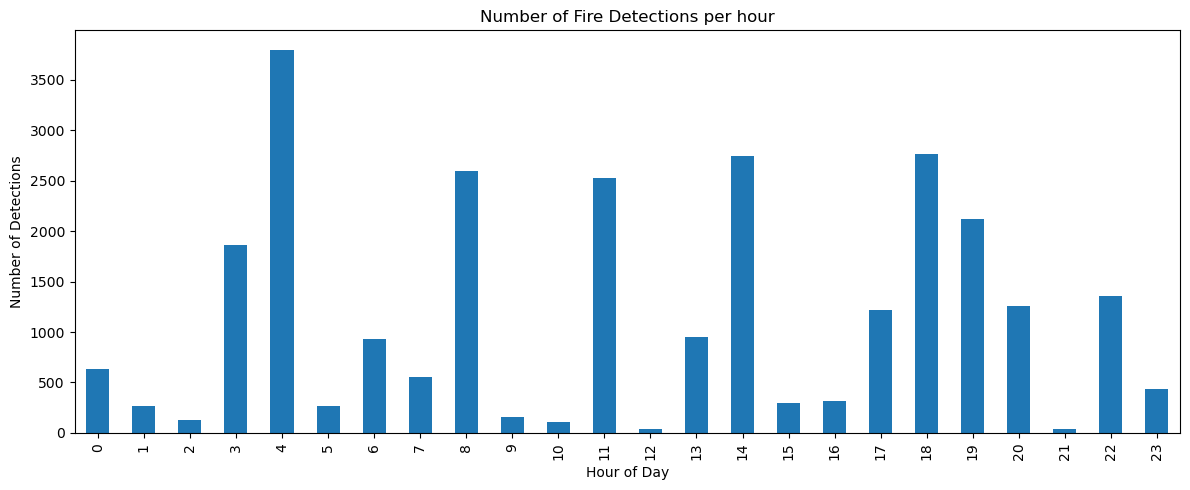

In [6]:
hourly_counts = gdf_filtered.groupby("hour").size()

plt.figure(figsize=(12,5))
hourly_counts.plot(kind="bar")

plt.title("Number of Fire Detections per hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Detections")

plt.tight_layout()
plt.show() 
# perhaps pattern caused by overflight over different terrains (ocean vs. terrestrial?)

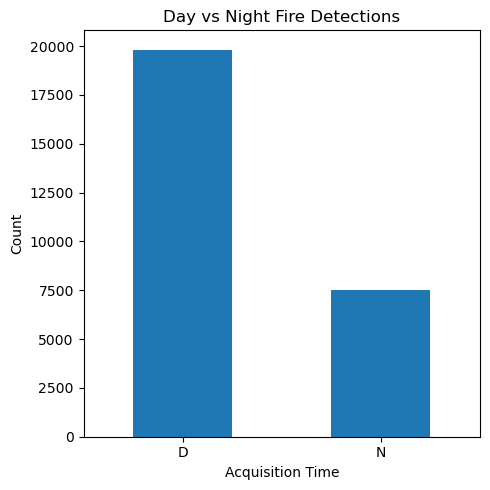

In [7]:
daynight_counts = gdf_filtered["daynight"].value_counts()

plt.figure(figsize=(5,5))
daynight_counts.plot(kind="bar")

plt.title("Day vs Night Fire Detections")
plt.xlabel("Acquisition Time")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Check Attribute values distributions (frp, confidence, brightness, scan size ?)

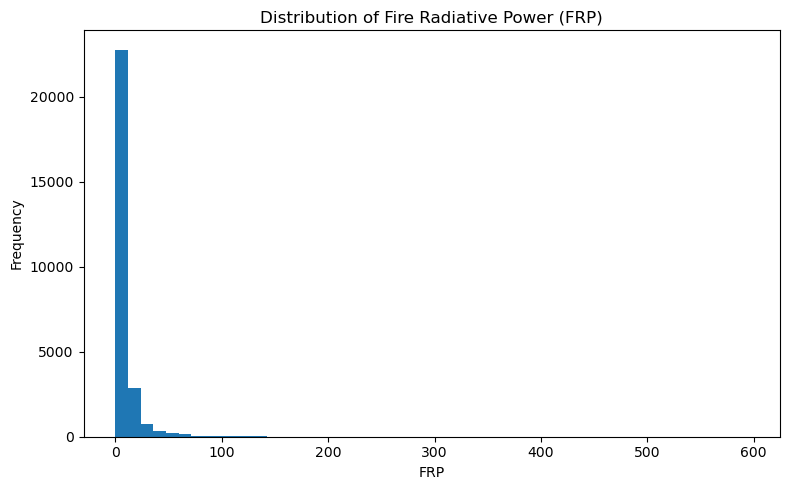

In [8]:
plt.figure(figsize=(8,5))

plt.hist(gdf_filtered["frp"], bins=50)

plt.title("Distribution of Fire Radiative Power (FRP)")
plt.xlabel("FRP")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [9]:
gdf_filtered["frp"].max() # outlier!!! rauswerfen

594.87

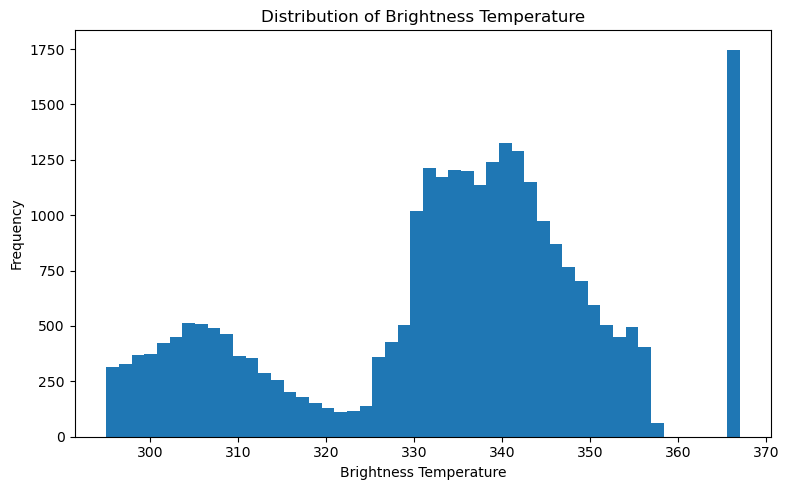

In [10]:
plt.figure(figsize=(8,5))

plt.hist(gdf_filtered["bright_ti4"], bins=50)

plt.title("Distribution of Brightness Temperature")
plt.xlabel("Brightness Temperature")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

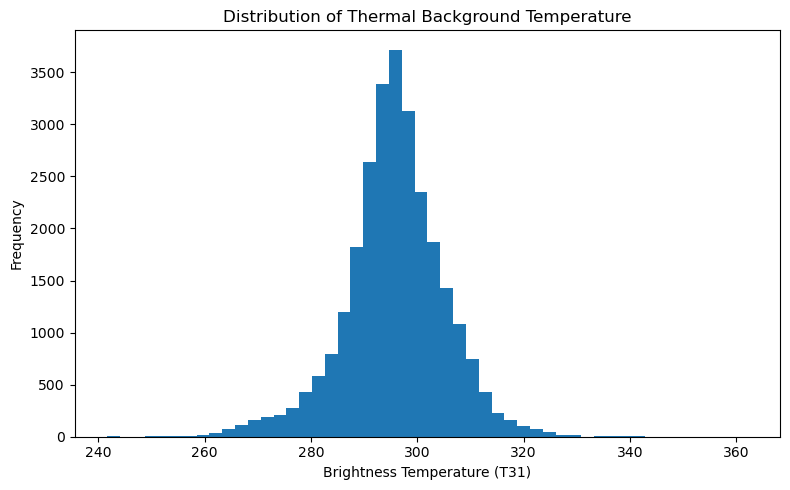

In [11]:
plt.figure(figsize=(8,5))

plt.hist(gdf_filtered["bright_ti5"], bins=50)

plt.title("Distribution of Thermal Background Temperature")
plt.xlabel("Brightness Temperature (T31)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

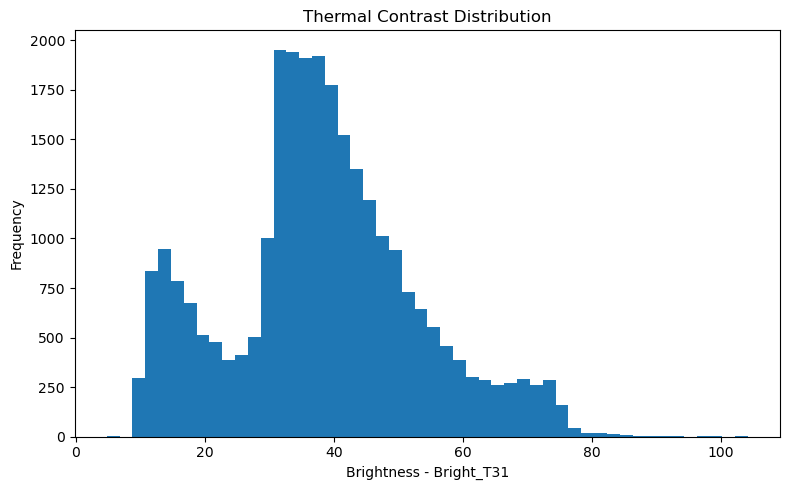

In [12]:
gdf_filtered["temp_diff"] = (
    gdf_filtered["bright_ti4"] -
    gdf_filtered["bright_ti5"]
)

plt.figure(figsize=(8,5))

plt.hist(gdf_filtered["temp_diff"], bins=50)

plt.title("Thermal Contrast Distribution")
plt.xlabel("Brightness - Bright_T31")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [13]:
gdf_filtered[
    ["frp", "bright_ti4", "bright_ti5", "scan"]
].describe()

,frp,bright_ti4,bright_ti5,scan
count,27348.000000,27348.000000,27348.000000,27348.000000
mean,8.752447,334.002119,295.675047,0.455710
std,16.744428,17.885453,9.483278,0.091328
min,0.050000,295.010000,241.570000,0.320000
25%,2.410000,326.540000,290.870000,0.390000
50%,4.770000,336.820000,295.800000,0.430000
75%,8.870000,345.030000,301.170000,0.510000
max,594.870000,367.000000,362.180000,0.800000


In [ ]:
gdf_filtered.explore(
    column="temp_diff",
    cmap="hot",
    legend=True
)

------------------------------------------------------------------------------------------------------------------

## 4. Comparative Sensor Analysis
....

------------------------------------------------------------------------------------------------------------------

## 5. Spatial Analysis
basic clustering plots  
also add heatmap with folium.plugins import HeatMap$
how 

------------------------------------------------------------------------------------------------------------------

## 6. Interactive Visualization
To-Do's:
- Datetime columns umformatieren zu string -> **gibt evtl spezifische Funtion stringsf oder so, wo man auswählen kann, welchen Teil vom DateTime type übernommen wird = Recherche !**
- Clustering -> **evtl einfach für visualizierung oder sonst um grösstes Cluster zu finden (dann aber mit matplotlib)**
- add tooltips -> **noch auswählen welche Daten alle zeigen**
- Layer Control für unterschiedliche Fire properties -> **gibt es irgendeine Funktion wie man zu diesen Properties jeweils noch eine Beschreibung/Info hinzufügen kann ????**, **Allg noch schauen bzgl. Comparative Analysis von verschiedenen Sources ???**


In [25]:
# check CRS of gdf
gdf_filtered = gdf_filtered.to_crs(epsg=4326)

# make copy of dataframe and convert DateTime columns to strings (Datetime objects CANNOT be visualized by folium)
gdf_map = gdf_filtered.copy()
gdf_map["datetime"] = (
    gdf_map["datetime"]
    .dt.strftime("%Y-%m-%d %H:%M")
)

gdf_map["acq_date"] = (
    gdf_map["acq_date"]
    .dt.strftime("%Y-%m-%d")
)
gdf_map.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 27348 entries, 0 to 30218
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   latitude    27348 non-null  float64 
 1   longitude   27348 non-null  float64 
 2   bright_ti4  27348 non-null  float64 
 3   scan        27348 non-null  float64 
 4   track       27348 non-null  float64 
 5   acq_date    27348 non-null  object  
 6   acq_time    27348 non-null  object  
 7   satellite   27348 non-null  object  
 8   instrument  27348 non-null  object  
 9   confidence  27348 non-null  object  
 10  version     27348 non-null  object  
 11  bright_ti5  27348 non-null  float64 
 12  frp         27348 non-null  float64 
 13  daynight    27348 non-null  object  
 14  datetime    27348 non-null  object  
 15  geometry    27348 non-null  geometry
 16  year        27348 non-null  int32   
 17  month       27348 non-null  int32   
 18  day         27348 non-null  int32   
 19  h

In [20]:
# initializing basemap
map1 = folium.Map(zoom_start = 12, tiles = "CartoDB Positron")

# Create an empty MarkerCluster group and add it to the map
#marker_cluster = MarkerCluster(name="name").add_to(map1)

# add layers and tooltips
#folium.GeoJson(gdf_map#,
              #name=,
              #tooltip=folium.GeoJsonTooltip(fields=["..."], aliases=["alias:"),
              #marker=folium.Marker(icon=folium.Icon()),
    #          ).add_to(map1)

# add layer control menu
folium.LayerControl().add_to(map1)

# add tooltips

# make datapoint clusters

map1